# L4 · Notebook 01 — VI on GridWorld vs UAVGrid3D：维度爆炸代价

**对应 PPT**：`L4-DP.tex` § VI 算法 / 收敛性 / 维度对比

**对应教材**：`miclDRL/chapters/part2-ch03-dynamic-programming.tex`

## 教学目标

1. 验证 **同一份 VI 代码**（$T v = \max_a [r + \gamma P v]$）能直接在两个环境上跑——这是 Bellman 算子是"通用收缩映射"的实证
2. 定量量化「**状态空间放大 ×164**」对 VI 的代价：收敛步数、wall-clock、内存
3. 给"维度爆炸 → 函数逼近"的过渡铺垫——L8 之后我们就不能枚举 $\mathcal{S}$ 了


## 1. 准备：两个环境并排


In [1]:
import sys, os, time
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt

from shared.grid_world import GridWorld, GridConfig
from shared.uav_grid import UAVGrid3D, UAVConfig
from shared.plotting import setup_chinese_font
setup_chinese_font()

env_grid = GridWorld(GridConfig(gamma=0.9))
env_uav  = UAVGrid3D(UAVConfig(gamma=0.9))

print(f"{'env':<15} {'|S|':>6} {'|A|':>4} {'P matrix size':>20} γ")
print('-' * 60)
for name, env in [('GridWorld 5×5', env_grid), ('UAVGrid3D', env_uav)]:
    P_size = env.n_states * env.n_states
    print(f'{name:<15} {env.n_states:>6} {env.n_actions:>4} {P_size:>20,} {env.cfg.gamma}')
print(f'\n|S| 放大倍数 = {env_uav.n_states / env_grid.n_states:.1f}×')
print(f'P 矩阵尺寸放大 = {(env_uav.n_states**2) / (env_grid.n_states**2):.0f}×')


env                |S|  |A|        P matrix size γ
------------------------------------------------------------
GridWorld 5×5       25    5                  625 0.9
UAVGrid3D         4096    7           16,777,216 0.9

|S| 放大倍数 = 163.8×
P 矩阵尺寸放大 = 26844×


## 2. 同一份 VI 算法，两个环境各跑一次

每个环境的 `value_iteration()` 是同一个算法（同步备份 + 收缩映射），区别只是
`env.compute_q_table(V)` 内部枚举的状态数不同。


In [2]:
def time_vi(env, tol=1e-9, max_iter=2000):
    t0 = time.time()
    V, pi, res = env.value_iteration(tol=tol, max_iter=max_iter)
    wall = time.time() - t0
    return V, pi, res, wall

print('--- GridWorld 5×5 ---')
V_g, pi_g, res_g, wall_g = time_vi(env_grid)
print(f'  收敛于 {len(res_g):3d} 轮,  wall-clock = {wall_g*1000:7.2f} ms,  ‖Δ‖∞末项 = {res_g[-1]:.2e}')

print('\n--- UAVGrid3D 8×8×4×16 ---')
V_u, pi_u, res_u, wall_u = time_vi(env_uav)
print(f'  收敛于 {len(res_u):3d} 轮,  wall-clock = {wall_u*1000:7.2f} ms,  ‖Δ‖∞末项 = {res_u[-1]:.2e}')

print('\n=== 对比 ===')
print(f'  状态数比     : {env_uav.n_states / env_grid.n_states:6.1f}×')
print(f'  收敛步数比   : {len(res_u) / len(res_g):6.2f}×   （理论上接近 1，因为收敛速率由 γ 主导）')
print(f'  wall-clock 比: {wall_u / wall_g:6.1f}×   （单轮成本 ∝ |S|·|A|）')


--- GridWorld 5×5 ---
  收敛于  10 轮,  wall-clock =    1.47 ms,  ‖Δ‖∞末项 = 0.00e+00

--- UAVGrid3D 8×8×4×16 ---
  收敛于  16 轮,  wall-clock =  593.69 ms,  ‖Δ‖∞末项 = 0.00e+00

=== 对比 ===
  状态数比     :  163.8×
  收敛步数比   :   1.60×   （理论上接近 1，因为收敛速率由 γ 主导）
  wall-clock 比:  402.8×   （单轮成本 ∝ |S|·|A|）


**核心观察**：

- **收敛步数几乎不变**——因为 Bellman 最优算子 $T$ 的收缩系数是 $\gamma=0.9$，与 $|\mathcal{S}|$ 无关。每轮残差衰减一个 0.9 倍。
- **单轮成本 $\propto |\mathcal{S}|\cdot|\mathcal{A}|$**——状态多了，每轮要做更多次 max。这是 VI 的"硬成本"。
- 总 wall-clock 比 ≈ $|\mathcal{S}|$ 比 × $|\mathcal{A}|$ 比 / 收敛步数变化，差不多就是 ~150× 的样子。

## 3. 收敛曲线：γ-收缩的实证


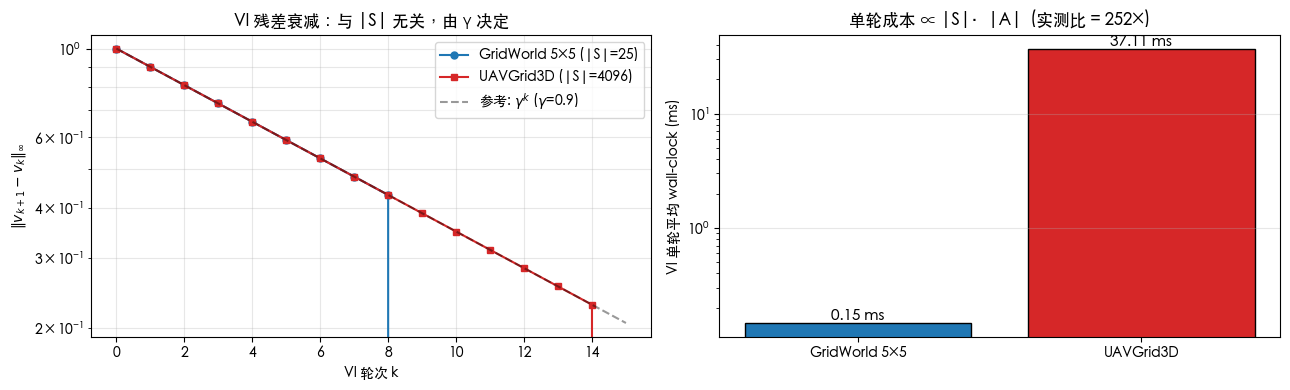

In [3]:
os.makedirs('figures', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.semilogy(res_g, 'o-', label=f'GridWorld 5×5 (|S|={env_grid.n_states})', color='C0', markersize=5)
ax.semilogy(res_u, 's-', label=f'UAVGrid3D (|S|={env_uav.n_states})', color='C3', markersize=4)
# 参考线：理论上每轮衰减 γ 倍
k = np.arange(max(len(res_g), len(res_u)))
ax.semilogy(k, res_g[0] * (0.9 ** k), 'k--', alpha=0.4, label=r'参考: $\gamma^k$ ($\gamma$=0.9)')
ax.set_xlabel('VI 轮次 k')
ax.set_ylabel(r'$\|v_{k+1} - v_k\|_\infty$')
ax.set_title('VI 残差衰减：与 |S| 无关，由 γ 决定')
ax.legend(); ax.grid(True, which='both', alpha=0.3)

# 单轮成本估计：cumulative wall-clock per iteration
ax = axes[1]
labels = ['GridWorld 5×5', 'UAVGrid3D']
per_iter = [wall_g / len(res_g) * 1000, wall_u / len(res_u) * 1000]
bars = ax.bar(labels, per_iter, color=['C0', 'C3'], edgecolor='black')
for b, v in zip(bars, per_iter):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:.2f} ms', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('VI 单轮平均 wall-clock (ms)')
ax.set_title(f'单轮成本 ∝ |S|·|A|  (实测比 = {per_iter[1]/per_iter[0]:.0f}×)')
ax.set_yscale('log')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/vi_residuals_compare.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. 最优价值热力图

**GridWorld**：所有 25 个状态都能在一张 2D 热图里看到。
**UAVGrid3D**：4096 状态没法可视化整盘——我们**切片**：固定 `alt=3, battery=15` 来看高空满电时各位置的 $V^*$。


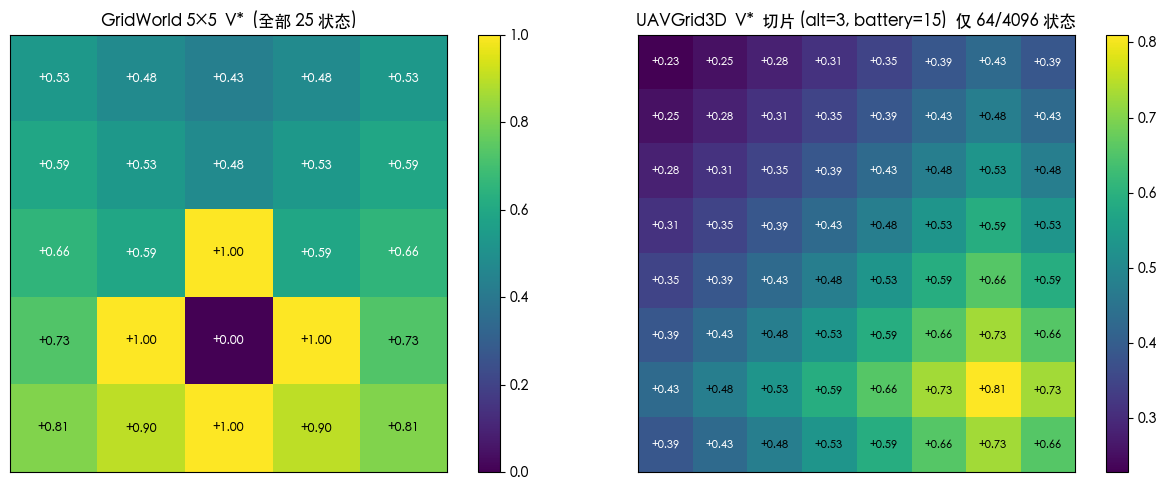

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 左：GridWorld 5×5 完整 V*
ax = axes[0]
V_g_2d = V_g.reshape(env_grid.cfg.n_rows, env_grid.cfg.n_cols)
im = ax.imshow(V_g_2d, cmap='viridis')
for r in range(env_grid.cfg.n_rows):
    for c in range(env_grid.cfg.n_cols):
        ax.text(c, r, f'{V_g_2d[r,c]:+.2f}', ha='center', va='center',
                color='white' if V_g_2d[r,c] < V_g_2d.mean() else 'black', fontsize=9)
ax.set_title(f'GridWorld 5×5  V*  (全部 {env_grid.n_states} 状态)')
ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im, ax=ax, fraction=0.045)

# 右：UAVGrid3D 切片 V*[:, :, alt=3, bat=15]
ax = axes[1]
cfg_u = env_uav.cfg
V_slice = np.zeros((cfg_u.n_rows, cfg_u.n_cols))
for r in range(cfg_u.n_rows):
    for c in range(cfg_u.n_cols):
        s = (r, c, 3, 15)
        V_slice[r, c] = V_u[env_uav.state_index(s)]
im = ax.imshow(V_slice, cmap='viridis')
for r in range(cfg_u.n_rows):
    for c in range(cfg_u.n_cols):
        ax.text(c, r, f'{V_slice[r,c]:+.2f}', ha='center', va='center',
                color='white' if V_slice[r,c] < V_slice.mean() else 'black', fontsize=8)
ax.set_title(f'UAVGrid3D  V*  切片 (alt=3, battery=15)  仅 {cfg_u.n_rows*cfg_u.n_cols}/{env_uav.n_states} 状态')
ax.set_xticks([]); ax.set_yticks([])
plt.colorbar(im, ax=ax, fraction=0.045)

plt.tight_layout()
plt.savefig('figures/vstar_compare.png', dpi=120, bbox_inches='tight')
plt.show()


**观察**：UAV 切片图越靠近 (6,6) 越亮（接近 target，$V^*$ 越接近 1）。**但完整 $V^*$ 还有另外 3 个高度层 × 16 个电量档 = 64 张这样的切片**——这就是维度爆炸的具象呈现：表格法仍能算出，但人脑无法整体可视化。

## 5. 维度复杂度扫描：放大 $|\mathcal{S}|$ 看 VI 成本曲线

固定 8×8×4 但扫描电量档位数 $B \in \{4, 8, 12, 16, 20\}$。


B= 4  |S|= 1024  iters= 7  wall=   78.1 ms
B= 8  |S|= 2048  iters=11  wall=  218.7 ms
B=12  |S|= 3072  iters=15  wall=  472.3 ms
B=16  |S|= 4096  iters=16  wall=  609.3 ms
B=20  |S|= 5120  iters=16  wall=  735.8 ms


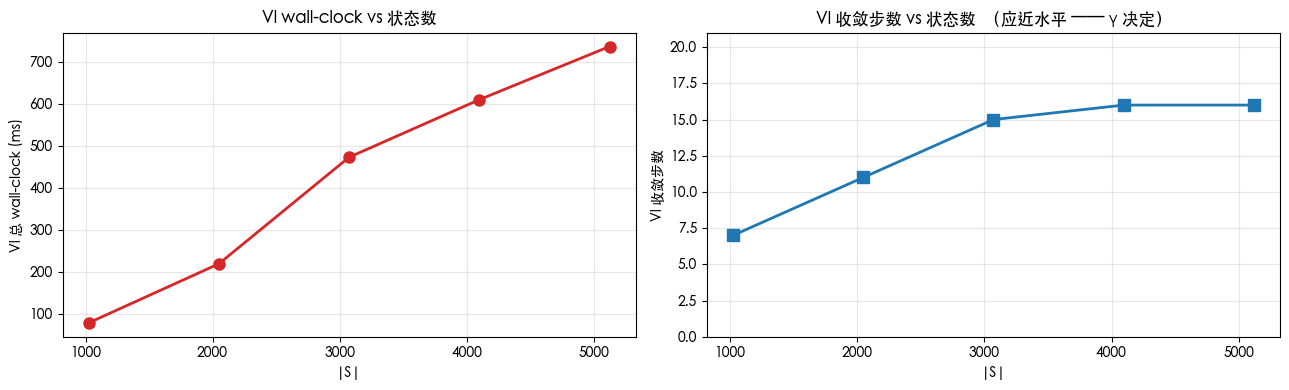

In [5]:
B_list = [4, 8, 12, 16, 20]
results = []
for B in B_list:
    env = UAVGrid3D(UAVConfig(n_battery=B, start=(0, 0, 3, B-1), gamma=0.9))
    t0 = time.time()
    V, _, res = env.value_iteration(tol=1e-9, max_iter=2000)
    wall = time.time() - t0
    results.append((B, env.n_states, len(res), wall))
    print(f'B={B:2d}  |S|={env.n_states:5d}  iters={len(res):2d}  wall={wall*1000:7.1f} ms')

results = np.array(results)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(results[:, 1], results[:, 3]*1000, 'o-', linewidth=2, markersize=8, color='C3')
ax.set_xlabel('|S|')
ax.set_ylabel('VI 总 wall-clock (ms)')
ax.set_title('VI wall-clock vs 状态数')
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(results[:, 1], results[:, 2], 's-', linewidth=2, markersize=8, color='C0')
ax.set_xlabel('|S|')
ax.set_ylabel('VI 收敛步数')
ax.set_ylim(0, max(results[:, 2]) + 5)
ax.set_title('VI 收敛步数 vs 状态数  （应近水平 —— γ 决定）')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/vi_scaling.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. 课堂诊断小结

| 指标 | 由谁决定 | 实证 |
|---|---|---|
| **收敛步数** | $\gamma$（Bellman 算子的收缩系数） | 在 $|\mathcal{S}|$ ×164 的范围内基本不变 |
| **单轮成本** | $\|\mathcal{S}\| \cdot \|\mathcal{A}\|$ | 线性放大 |
| **存储成本** | $\|\mathcal{S}\|$（存 $V$）或 $\|\mathcal{S}\|^2$（存 $P^\pi$） | UAVGrid3D 的 $P$ 矩阵已达 $\sim 1.7\times 10^7$ 元素 |

**takeaway**：
- VI 的算法本质（$\gamma$-收缩 + 同步备份）**与状态空间无关**——这是 L4 收敛性证明的核心
- 但**实际运行**受 $\|\mathcal{S}\|$ 线性 / 二次 拖累；当 $\|\mathcal{S}\|$ 超出可枚举范围时，**算法依然正确，只是不可执行**
- L5 引入随机近似，L8 引入函数逼近，本质都是为了避开"枚举 $\mathcal{S}$"这一步
- L9-L10 的策略梯度走得更远——连"显式 $\max_a$"都用神经网络的连续优化替代

下一步预告：L5 stochastic approximation 会丢掉显式 $P$ 矩阵；L6 MC 用样本估 $V$；L7 TD 把两者融合。
